In [18]:
%load_ext autoreload
%autoreload 2

import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

import os
import pandas as pd
from torch.utils.data import Dataset
# import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import sys
sys.path.insert(0, '../')
from utils import *
import matplotlib.pyplot as plt
import wandb
import datetime

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
print(np)

<module 'numpy' from '/home/egp8636/.conda/envs/ML/lib/python3.12/site-packages/numpy/__init__.py'>


## Confusion Matrix Comparison ##

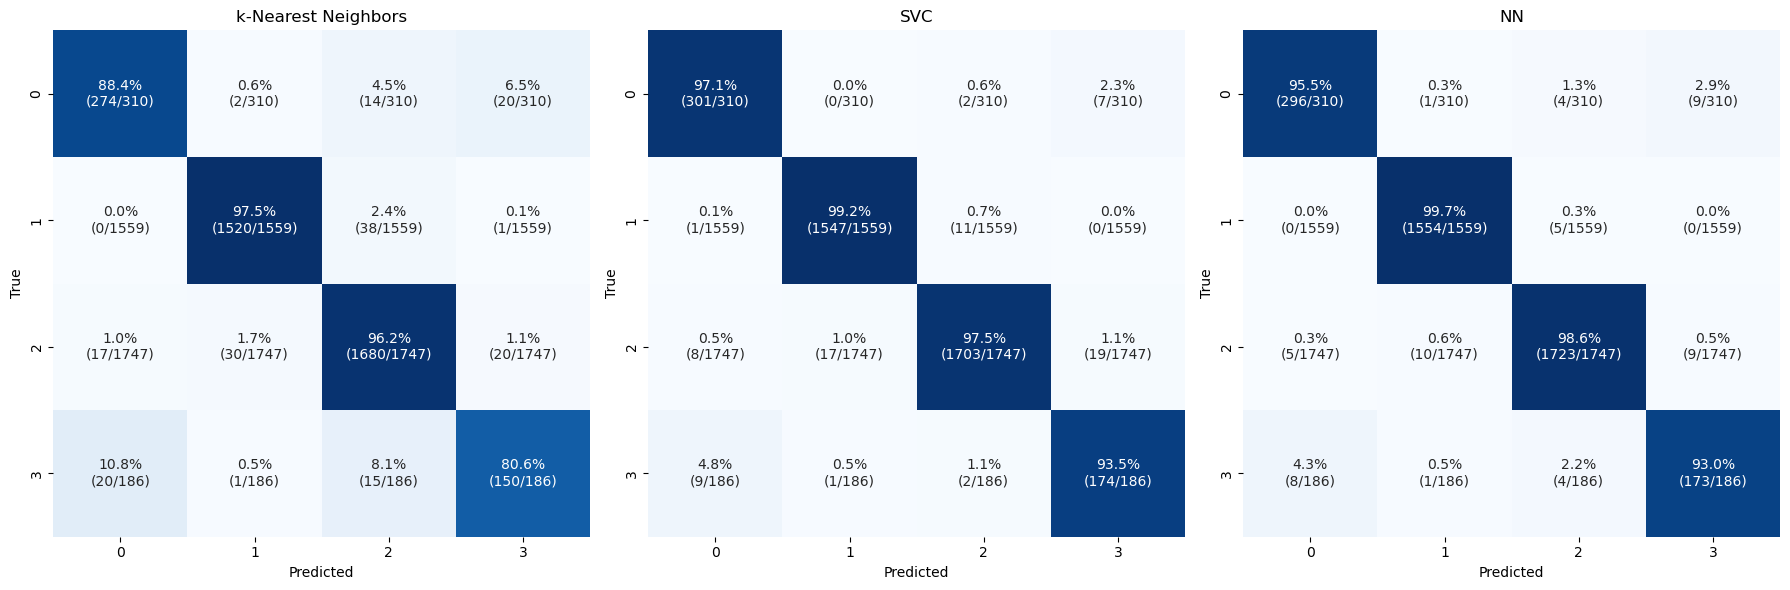

In [10]:
#-- Load the data 

data = np.load('data_splits_splot22f_1008.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

# Create panel with all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#-- Load the kNN model 

knn_results = np.load('results/knn_results.npz', allow_pickle=True)
y_pred_knn = knn_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_knn, 'k-Nearest Neighbors', ax=axes[0])

#-- Load the SVM model 

svm_results = np.load('results/svm_results.npz', allow_pickle=True)
y_pred_svm = svm_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_svm, 'SVC', ax=axes[1])

#-- Load the NN model 
NN_results = np.load('results/NN_results.npz', allow_pickle=True)
y_pred_NN = NN_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_NN, 'NN', ax=axes[2])

plt.tight_layout()
fig.savefig('figures/confusion_matrices_panel.png', dpi=300, bbox_inches='tight')
plt.show()


## Decision Boundaries Comparison ##

In [32]:
def load_and_plot_SVC(feature_idx, fixed_values={}, labels=[], method = 'kNN'):

    import joblib
    sys.path.insert(0, './NN/')

    import os
    print(os.getcwd())
    
    # --- Load saved model, scaler, and results ---

    data = np.load('data_splits_splot22f_1008.npz')
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
    X_test, y_test = data['X_test'], data['y_test']

    if method == 'SVC':
        model = joblib.load('best_models/svm_best_model.pkl')
        scaler = joblib.load('best_models/svm_scaler.pkl')
    elif method == 'kNN':
        print('here')
        model = joblib.load('best_models/knn_best_model.pkl')
        scaler = joblib.load('best_models/knn_scaler.pkl')
    elif method == 'NN':
        from NN_classification import NeuralNetwork
        model_name = 'best_models/model_1018_ua7nca53.pt'
        model = NeuralNetwork()
        checkpoint = torch.load(model_name, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint["model_state_dict"])
        scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
        

    # --- Generate the plot ---
    fig = N_gridsearch_plotter(X_train, y_train, X_test, y_test, X_val, y_val,
                             model=model,
                             scaler=scaler,
                             feature_idx=feature_idx,
                             fixed_values=fixed_values,
                             labels=labels,
                             method = method)

    return fig

def N_gridsearch_plotter(X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, feature_idx, fixed_values={}, labels = [], method = 'kNN', num_classes = 4):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - X_train, X_test, X_val: float arrays, containing (unnormalized) data for training, testing, and validation sets 
    - y_train, y_test, y_val: float arrays, containing (unnormalized) labels for training, testing, and validation sets 
    - model: Trained model.
    - scaler: to be used to transfor the data into the format taken by the model
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions. Unnormalized (same format as train/test/val tests)
    - labels:  list of strings 
    - method: method to evaluate
    """

    # Step 1: Filter train and test data based on fixed_values
    unique_times = np.unique(X_train[:,3])

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

    # Step 4: Standard normalize the data like you did before
    fixed_values_norm = {}
    if method == 'SVC' or method == 'kNN':
        xx_norm = (xx - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]]
        yy_norm = (yy - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - scaler.mean_[k]) / scaler.scale_[k]
        
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
        yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid

    if method == 'SVC' or method == 'kNN':
        Z = model.predict(X_vis)
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            Z = model(X_vis).argmax(dim=1).numpy()

    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        cmap_base = plt.cm.coolwarm
        norm_base = mcolors.Normalize(vmin=0, vmax=2)
        # Build a list of colors by evaluating cmap for labels 0, 1, 2
        colors = [cmap_base(norm_base(i)) for i in range(3)]

        # Append a custom color for label 3 (e.g., green)
        colors.append((0.13, 0.55, 0.13, 1.0))  # green

        # Create a discrete colormap
        cmap = mcolors.ListedColormap(colors)

        # Define norm for discrete class labels 0–3
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)


    # Step 5: Plot decision boundary
    fig, ax = plt.subplots()
    plt.contourf(10**xx-1, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

    # print(X_train_filtered_unnorm[:, feature_idx[1]])

    print(np.min(X_train_filtered[:, feature_idx[0]]))
    print(np.min(10**X_train_filtered[:, feature_idx[0]] -1))
    plt.scatter(10**X_train_filtered[:, feature_idx[0]] -1, X_train_filtered[:, feature_idx[1]], c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o', label = 'Train')
    plt.scatter(10**X_val_filtered[:, feature_idx[0]] -1, X_val_filtered[:, feature_idx[1]], c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s', label = 'Val')
    plt.scatter(10**X_test_filtered[:, feature_idx[0]]-1, X_test_filtered[:, feature_idx[1]], c=y_test_filtered, cmap=cmap, norm = norm, marker='^', label = 'Test' )
    plt.xlabel(fr" {labels[0]}", fontsize = 15)
    plt.ylabel(fr" {labels[1]}", fontsize = 15)
    plt.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer
    plt.legend()
    plt.title(
    fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round((float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)

    plt.tight_layout()
    return fig
    

In [27]:
print(np.min(X_train[:,0]))
print(np.min(X_val[:,0]))
print(np.min(X_test[:,0]))
print(np.log10(0 + 0.001))

index = np.where()

-3.0
-3.0
-3.0
-4.0


************************************************************
-3.0 3.4657359027997265 3.4657359027997265
/projects/b1095/egp8636/ML_SPH/classification


/tmp/ipykernel_3249284/4039183049.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_name, map_location=torch.device('cpu'))


0.0
0.0


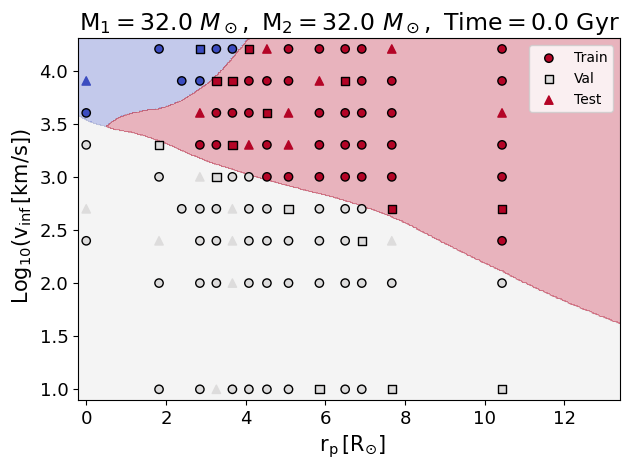

In [33]:

data = np.load('data_splits_splot22f_1008.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

from matplotlib.backends.backend_pdf import PdfPages

unique_pairs = np.unique(X_train[:, [0, 3, 4]], axis=0)
# unique_pairs = [unique_pairs[0]]
# print(unique_pairs)

unique_pairs = [[np.log10(0 + 0.001), np.log(32.), np.log(32.)]]
# with PdfPages('decision_boundary_plots_22f_10_22.pdf') as pdf:
with PdfPages('test.pdf') as pdf:

    for unique in unique_pairs:
        time, mass1, mass2 = unique[0], unique[1], unique[2]
        print('*'*60)
        print(time, mass1, mass2)
        
        labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(mass1), str(round(mass2,2))]
        labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', 
                  str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
                  str(10**(time) - 0.001)]
        
        fig = load_and_plot_SVC(feature_idx=(1, 2), 
                                fixed_values={0: time, 3: mass1, 4: mass2}, 
                                labels=labels, method='NN')
        
        if fig != None:
            # Save the current figure to the PDF
            pdf.savefig(fig, bbox_inches='tight')
            plt.show()
            plt.close(fig)


In [32]:
# def N_gridsearch_plotter(X_train, y_train, X_test, y_test, svc, svc_scaler, feature_idx, fixed_values={}, labels = [], num_classes = 4, method = 'NN'):

    # import joblib
    # # Xtrain is not standard normalized, neither are the features and fixed values, but they are given in the correct transformstion 

    # # Step 1: Filter train and test data based on fixed_values
    # print(fixed_values)
    # train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    # test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])

    # if (train_mask.sum() == 0 and test_mask.sum() == 0):
    #     return "No data points!"

    # X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    # X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # # Step 2: Create a meshgrid for the chosen two features
    # x_min, x_max = X_train_filtered[:, feature_idx[0]].min() -0.1, X_train_filtered[:, feature_idx[0]].max() + 0.01
    # y_min, y_max = X_train_filtered[:, feature_idx[1]].min() -0.1, X_train_filtered[:, feature_idx[1]].max()  + 0.1
    
    # xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
    
    # # Step 3: Construct full-dimensional input space for predictions
    # X_grid = np.zeros((xx.ravel().shape[0], X_train.shape[1]))
    # X_grid[:, feature_idx[0]] = xx.ravel()
    # X_grid[:, feature_idx[1]] = yy.ravel()

    # # Assign fixed values to other dimensions
    # for k, v in fixed_values.items():
    #     X_grid[:, k] = v  

    # #transform the data
    # X_grid_scaled = svc_scaler.transform(X_grid)
 
    # #Predict labels for meshgrid

    # if method == 'SVC':
    #     best_model = joblib.load('best_models/svm_best_model.pkl')
    #     Z = best_model.predict(X_grid_scaled)
    # elif method == 'kNN':
    #     best_model = joblib.load('best_models/knn_best_model.pkl')
    #     Z = best_model.predict(X_grid_scaled)
    # elif method == 'NN':
    #     model.eval()
    #     with torch.no_grad():
    #         Z = model(X_vis).argmax(dim=1).numpy()

    # else:
    #     return print("Please enter a correct method")
        
    # Z = Z.reshape(xx.shape)

    # # # Normalize color mapping to match the scatter points and contour
    # # cmap = plt.cm.coolwarm  # Set the same colormap
    # # norm = mcolors.Normalize(vmin=Z.min(), vmax=Z.max())  # Normalize colors

    # # Normalize color mapping to match the scatter points and contour
    # cmap = plt.cm.coolwarm  # Set the same colormap
    # norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    # if num_classes >= 4: 

    #     cmap_base = plt.cm.coolwarm
    #     norm_base = mcolors.Normalize(vmin=0, vmax=2)
    #     # Build a list of colors by evaluating cmap for labels 0, 1, 2, 3
    #     colors = [cmap_base(norm_base(i)) for i in range(num_classes)]

    #     # Append a custom color for label 3 (e.g., green)
    #     colors.append((0.13, 0.55, 0.13, 1.0))  # green

    #     # Create a discrete colormap
    #     cmap = mcolors.ListedColormap(colors)

    #     # Define norm for discrete class labels 0–3
    #     norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

    # # Plot decision boundary
    # plt.contourf(10**xx-1, yy, Z, alpha=0.3, cmap=cmap, norm=norm)
    # # plt.xlim(x_min-0.1, x_max)
    # #--- Overplot the data ---#

    # plt.scatter(10**X_train_filtered[:, feature_idx[0]]-1, X_train_filtered[:, feature_idx[1]],  c=y_train_filtered,  cmap=cmap, norm = norm,  edgecolor="k", marker='o', label = 'Train' )
    # plt.scatter(10**X_test_filtered[:, feature_idx[0]]-1, X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k" , marker='^', label = 'Test')

    # #--- Plot settings ---#

    # plt.title(
    # fr"SVM $\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)
    # plt.xlabel(fr" {labels[0]}", fontsize = 15)
    # plt.ylabel(fr" {labels[1]}", fontsize = 15)
    # plt.legend()
    # plt.show()
    # plt.tight_layout()

2.772588722239781


In [ ]:
#-- Load the data 

data = np.load('data_splits_splot22f.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

# Create panel with all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#-- Load the kNN model 

knn_results = np.load('results/knn_results.npz', allow_pickle=True)
y_pred_knn = knn_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_knn, 'k-Nearest Neighbors', ax=axes[0])

#-- Load the SVM model 

svm_results = np.load('results/svm_results.npz', allow_pickle=True)
y_pred_svm = svm_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_svm, 'SVC', ax=axes[1])

#-- Load the NN model 
NN_results = np.load('results/NN_results.npz', allow_pickle=True)
y_pred_NN = NN_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_NN, 'NN', ax=axes[2])

plt.tight_layout()
fig.savefig('figures/confusion_matrices_panel.png', dpi=300, bbox_inches='tight')
plt.show()
